# **- 머신러닝(딥러닝) 프로젝트 진행 절차**

### - 라이브러리 임포트
        - 실습에 필요한 라이브러리를 임포트합니다.

In [1]:
# !pip install numpy pandas

In [2]:
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

# skLearc train_test_split의 동일한 결과 출력을 위해 선언
np.random.seed(75) # seed 값 고정


# 1. 문제 정의  
##### - 농구 선수의 경기 기록을 바탕으로, 그 선수의 포지션을 예측해보도록 하겠습니다.

# 2. 데이터 수집

In [3]:
# 데이터를 수집합니다.

import os

# df = pd.read_csv('data/csv/basketball_stat.csv')
# print("현재 작업 위치:", os.getcwd())
df = pd.read_csv("basketball_stat.csv")

In [ ]:
# 수집된 데이터 샘플 확인
df.head()
# df.describe()

,Player,Pos,3P,2P,TRB,AST,STL,BLK
0,Alex Abrines,SG,1.4,0.6,1.3,0.6,0.5,0.1
1,Steven Adams,C,0.0,4.7,7.7,1.1,1.1,1.0
2,Alexis Ajinca,C,0.0,2.3,4.5,0.3,0.5,0.6
3,Chris Andersen,C,0.0,0.8,2.6,0.4,0.4,0.6
4,Will Barton,SG,1.5,3.5,4.3,3.4,0.8,0.5


In [4]:
# 현재 가지고 있는 데이터에서, 포지션의 갯수를 확인

df.Pos.value_counts()
# df.describe()


Pos
SG    50
C     50
Name: count, dtype: int64

# 3. 데이터 시각화  

##### - 데이터 특징을 바탕으로 한 공간에 시각화함으로써, 우리는 머신러닝 학습에 필요한 특징과 불필요한 특징을 쉽게 구분지을 수 있다.

In [6]:
# !pip install seaborn

In [5]:
import matplotlib.pyplot as plt  # 맷플롯립
import seaborn as sns  # seaborn 설치 시 matplotlib는 자동 설치됨

Text(0.5, 1.0, 'STL and 2P in 2d plane')

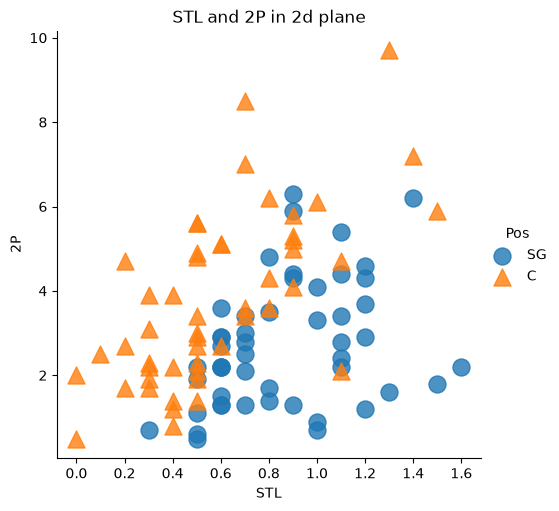

In [6]:
# 스틸, 2점슛 데이터 시각화(산점도)

sns.lmplot(data=df, x='STL', y='2P', hue='Pos', fit_reg=False,
           scatter_kws={"s":150}, markers=["o", "^"])  # featuere Pos를 기준으로 색상으로 시각화, fit_reg=False 고정된 회귀선 미표시, scatter_kws 좌표상의 점의 크기

# title
plt.title("STL and 2P in 2d plane")


Text(0.5, 1.0, 'AST and 2P in 2d plane')

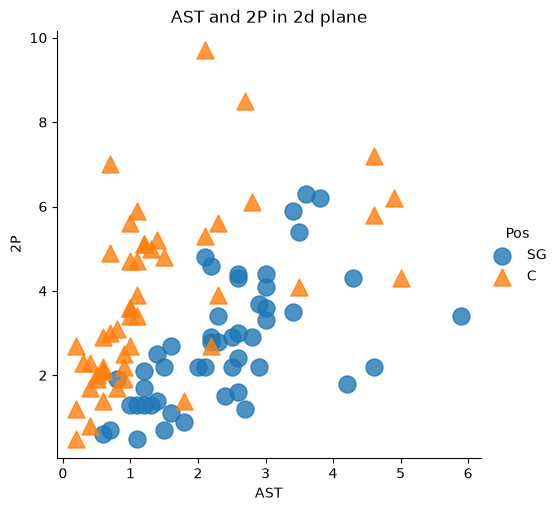

In [6]:
# 어시스트, 2점슛 데이터 시각화

sns.lmplot(data=df, x='AST', y='2P', hue='Pos', fit_reg=False, 
           scatter_kws={'s': 150}, markers=['o', '^'])

# title
plt.title('AST and 2P in 2d plane')


Text(0.5, 1.0, 'BLK and 3P in 2d plane')

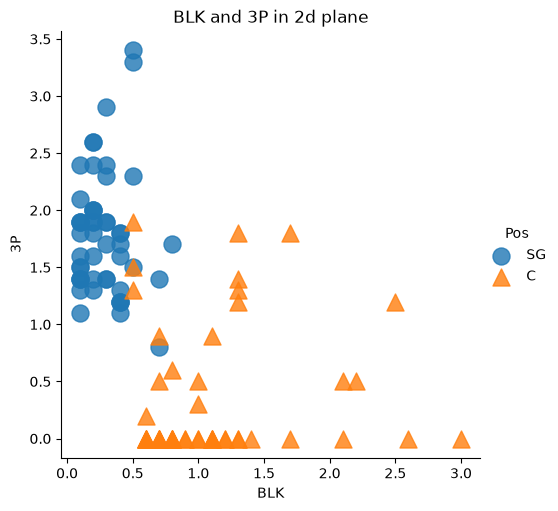

In [7]:
# 블로킹, 3점슛 데이터 시각화

sns.lmplot(data=df, x='BLK', y='3P', hue='Pos', fit_reg=False,
           scatter_kws={'s':150}, markers=['o', '^'])

# title
plt.title('BLK and 3P in 2d plane')

Text(0.5, 1.0, 'TRB and 3P in 2d plane')

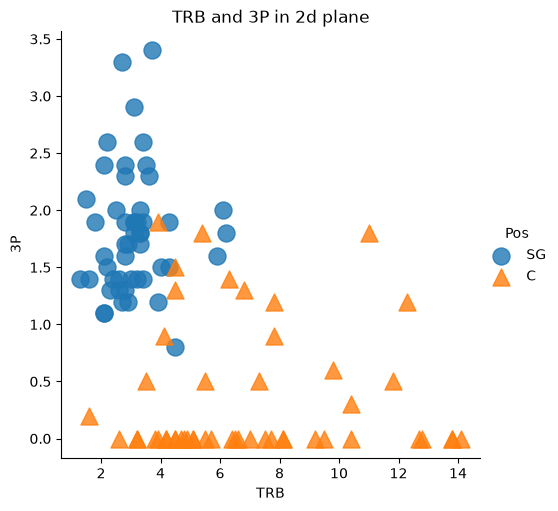

In [24]:
# 리바운드, 3점슛 데이터 시각화
sns.lmplot(data=df, x='TRB', y='3P', hue='Pos', fit_reg=False,
           scatter_kws={'s':150}, markers=['o', '^'])

# title
plt.title('TRB and 3P in 2d plane')

# 4. 데이터 다듬기(전처리)

In [8]:
# 전처리
# 분별력이 없는 특징(feature)을 데이터에서 제거.

# df 변수에 다시 할당하지 않고 그대로 실행
df.drop(['2P', 'AST', 'STL'], axis=1, inplace=True)

# 정상적으로 수정된 df의 상위 5개 행 출력
df.head()

,Player,Pos,3P,TRB,BLK
0,Alex Abrines,SG,1.4,1.3,0.1
1,Steven Adams,C,0.0,7.7,1.0
2,Alexis Ajinca,C,0.0,4.5,0.6
3,Chris Andersen,C,0.0,2.6,0.6
4,Will Barton,SG,1.5,4.3,0.5


# 5. 데이터 나누기(학습 데이터, 테스트 데이터)

In [ ]:
# !pip install scikit-learn
# sklearn 싸이킷런

In [9]:
from sklearn.model_selection import train_test_split

# 다듬어진 데이터에서 20%를 테스트 데이터로 분류
train, test = train_test_split(df, test_size=0.2) # 0.2 : 20% 데이터만 테스트 데이터로사용(tran 80%, test 20%)


In [10]:
# 학습 데이터의 갯수를 확인
train.shape[0]

80

In [11]:
# 테스트 데이터의 갯수를 확인
test.shape[0]

20

# 6. 보관(저장)

In [37]:
train.to_csv('basketball_train.csv', index=None)  # 행의 이름없이 저장
# train.to_csv('data/csv/basketball_train.csv')


In [38]:
test.to_csv('basketball_test.csv', index=None)